In [ ]:
pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [145]:
df = pd.read_csv("/content/spam.csv", encoding='latin1')

le = LabelEncoder()
scaler = StandardScaler()

for col in df:
  if df[col].dtype == "object":
    df[col] = le.fit_transform(df[col])
  else:
    df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))



for col in df:
  if df[col].isnull().sum() > 0 and df[col].dtype != "object":
    df.fillna(df[col].mean(), inplace=True)


y = df['v1']
x = df.drop(['v1'], axis=1)


In [133]:
y.value_counts()

,count
v1,
0,4825
1,747


In [134]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

print("Original y_train value counts:")
print(y_train.value_counts())
print("\nResampled y_train value counts (after SMOTE):")
print(y_resampled.value_counts())

Original y_train value counts:
v1
0    3860
1     597
Name: count, dtype: int64

Resampled y_train value counts (after SMOTE):
v1
0    3860
1    3860
Name: count, dtype: int64


In [136]:
y

,v1
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [137]:
print(df)

      v1    v2  Unnamed: 2  Unnamed: 3  Unnamed: 4
0      0  1079          43          10           5
1      0  3101          43          10           5
2      1  1000          43          10           5
3      0  4088          43          10           5
4      0  2757          43          10           5
...   ..   ...         ...         ...         ...
5567   1  3992          43          10           5
5568   0  4560          43          10           5
5569   0  3286          43          10           5
5570   0  3901          43          10           5
5571   0  3409          43          10           5

[5572 rows x 5 columns]


In [138]:
print(y_train)

1978    0
3989    1
3935    0
4078    0
4086    1
       ..
3772    0
5191    0
5226    0
5390    0
860     0
Name: v1, Length: 4457, dtype: int64


In [ ]:
# from xgboost import XGBRegressor

# from sklearn.metrics import (
#     r2_score,
#     mean_absolute_error,
#     mean_squared_error,
#     mean_squared_log_error,
#     median_absolute_error,
#     explained_variance_score  )

# xgb_model = XGBRegressor(
#    n_estimators=300,
#     learning_rate=0.1,
#     max_depth=5,

#     random_state=42,
#     n_jobs=-1,

#     colsample_bytree=0.7,
#     subsample=0.8,

#     objective='reg:squarederror',
#     tree_method='auto')

# xgb_model.fit(x_train, y_train)
# y_pred = xgb_model.predict(x_test)

# # accuracy_scores = accuracy_score(y_test, y_pred)
# # precision_scores = precision_score(y_test, y_pred)
# # recall_scores = recall_score(y_test, y_pred)
# # f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

# # print(f"""
# # Accuracy Score : {accuracy_scores}
# # Precision Score : {precision_scores}
# # Recall Score : {recall_scores}
# # F1 Score : {f1_scores} """)

# r2_score = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"R2 Score: {r2_score}")
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")

R2 Score: 0.8540069989703252
Mean Absolute Error: 0.22985792024127338
Mean Squared Error: 0.1546663049897595


In [ ]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass']) # Assuming binary classification for 'liked'
# disp.plot(cmap=plt.cm.Blues)
# plt.xlabel('Predicted student data')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

In [ ]:
# print(classification_report(y_test, y_pred))

In [143]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 7))
# # sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
# plt.title('Actual vs. Predicted price (Scaled)')
# plt.xlabel('Actual price (Scaled)')
# plt.ylabel('Predicted price(Scaled)')
# plt.grid(True)
# plt.show()

In [ ]:
df = pd.read_csv("/content/insurance2.csv")
print(df)

      age  sex     bmi  children  smoker  region      charges  insuranceclaim
0      19    0  27.900         0       1       3  16884.92400               1
1      18    1  33.770         1       0       2   1725.55230               1
2      28    1  33.000         3       0       2   4449.46200               0
3      33    1  22.705         0       0       1  21984.47061               0
4      32    1  28.880         0       0       1   3866.85520               1
...   ...  ...     ...       ...     ...     ...          ...             ...
1333   50    1  30.970         3       0       1  10600.54830               0
1334   18    0  31.920         0       0       0   2205.98080               1
1335   18    0  36.850         0       0       2   1629.83350               1
1336   21    0  25.800         0       0       3   2007.94500               0
1337   61    0  29.070         0       1       1  29141.36030               1

[1338 rows x 8 columns]


In [ ]:
df["insuranceclaim"].dtype

dtype('int64')

In [ ]:
df['insuranceclaim'].dtype

dtype('int64')

In [ ]:
print(y)

0       1
1       1
2       0
3       0
4       1
       ..
1333    0
1334    1
1335    1
1336    0
1337    1
Name: insuranceclaim, Length: 1338, dtype: int64


In [ ]:
y_train.value_counts()

,count
insuranceclaim,
1,622
0,448


In [144]:
y_test.value_counts()

,count
v1,
0,965
1,150


In [146]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"""
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")


x_train : (4457, 4)
x_test : (1115, 4)
y_train : (4457,)
y_test : (1115,)



In [147]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='binary:logistic'
    # tree_method='auto'
   )

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred)
recall_scores = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)

# r2_score = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"R2 Score: {r2_score}")
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")


Accuracy Score : 0.8753363228699551
Precision Score : 0.6486486486486487
Recall Score : 0.16
F1 Score : 0.25668449197860965 


              precision    recall  f1-score   support

           0       0.88      0.99      0.93       965
           1       0.65      0.16      0.26       150

    accuracy                           0.88      1115
   macro avg       0.77      0.57      0.59      1115
weighted avg       0.85      0.88      0.84      1115



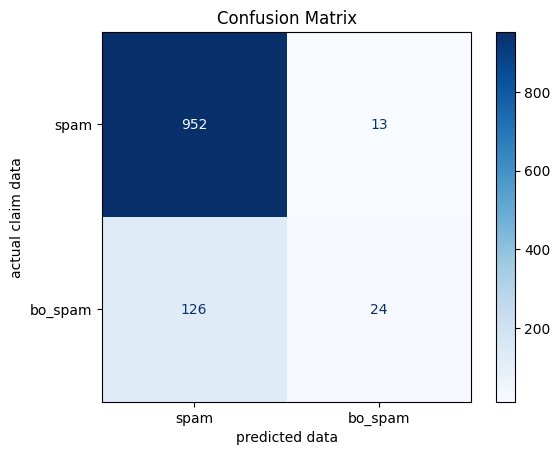

In [148]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['spam', 'bo_spam']) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)

plt.xlabel('predicted data')
plt.ylabel('actual claim data')
plt.title('Confusion Matrix')
plt.show()

In [142]:
import joblib
if joblib.dump(xgb_model, 'email_spam_detection.pkl'):
  print("model saved")

model saved
